# Jiminy Engine — Specialized Scenario Example (`jiminy.yaml`)

This notebook demonstrates the `jiminy.yaml` scenario, adapting the logic used in the `jiminy_cli.py` application. It models a complex ethical dilemma involving child safety, parental supervision, and access to alcohol.

In [8]:
import sys
import os
import yaml
from IPython.display import Image, display
from graphviz import Digraph

# Add the project root to the path so we can import jiminy
ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

## Loading the `jiminy.yaml` Scenario

We load the scenario and identify the default semantics defined in the YAML file.

In [9]:
scenario_path = "../scenarios/jiminy.yaml"
(
    possible_facts,
    norms,
    contrariness,
    priorities,
    context_desc,
    norm_desc,
    contrariness_desc,
    priority_desc,
    base_priorities,
    meta_priorities
) = load_scenario(scenario_path)

with open(scenario_path, "r") as f:
    yaml_data = yaml.safe_load(f)
    default_semantics = yaml_data.get("semantics", "priority")

print(f"Loaded scenario from {scenario_path}")
print(f"Default semantics: {default_semantics}")
print(f"Context facts: {list(possible_facts)}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
Loaded scenario from ../scenarios/jiminy.yaml
Default semantics: jiminy
Context facts: ['w1', 'w2', 'w3', 'w4']


## Initializing Jiminy

We create a `Jiminy` instance.

In [10]:
jim = Jiminy(
    norms,
    contrariness,
    priorities,
    context_desc,
    norm_desc,
    contrariness_desc,
    priority_desc
)

## Scenario Execution — Risk Case

We simulate the case: child access to alcohol + unsupervised (`w1, w2, w3, w4`).

The execution logic here mirrors `jiminy_cli.py`, using `compute_jiminy` for the two-phase normative detachment.

In [11]:
active_context = {'w1', 'w2', 'w3', 'w4'}
print(f"Active facts: {active_context}")

if default_semantics == "jiminy":
    print("Using JIMINY semantics (two-phase normative detachment)")
    E, P, O = jim.compute_jiminy(active_context)
    accepted_heads = E | P | O
    args_all = jim.generate_arguments(accepted_heads)
    
    accepted = [A for A in args_all if A.hd in accepted_heads]
    rejected = [A for A in args_all if A.hd not in accepted_heads]
    args_final = args_all
else:
    print(f"Using {default_semantics} semantics")
    args = jim.generate_arguments(active_context)
    accepted, rejected = jim.compute_extension(args, semantics=default_semantics)
    args_final = args

print("\n--- Final Moral Recommendation ---\n")
final_actions = sorted(A.hd for A in accepted if A.tau in ['r', 'p'])
for action in final_actions:
    print(f"ACCEPTED: {action} - {jim.norm_desc.get(action, '')}")

Active facts: {'w1', 'w2', 'w3', 'w4'}
Using JIMINY semantics (two-phase normative detachment)

--- Final Moral Recommendation ---

ACCEPTED: d3 - notify parent1
ACCEPTED: d4 - notify parent2
ACCEPTED: d5 - inform child about alcohol risks
ACCEPTED: d6 - robot may register the incident


## Full Explanation

Generate a detailed narrative explanation of the reasoning process.

In [12]:
explanation = jim.explain(
    accepted,
    rejected,
    active_context,
    generated_arguments=args_final,
    semantics=default_semantics,
    debug=True
)
print(explanation)

CONTEXT ANALYSIS
------------------------------------------------------------
 - w1: child1 is in room1
 - w2: bar cabinet is in room1
 - w3: parent1 is not in room1
 - w4: parent2 is not in room1

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w1', 'w2') ⇒ i1 (Institutional fact, stakeholder=Law)  # child has access to alcohol if in same room as cabinet
 - ('w1', 'w3', 'w4') ⇒ i2 (Institutional fact, stakeholder=Manuf)  # child is unsupervised if parents absent
 - ('i1', 'i2') ⇒ i3 (Institutional fact, stakeholder=Law)  # potential risk if unsupervised and access to alcohol
 - ('i1',) ⇒ i4 (Institutional fact, stakeholder=Family)  # no clear risk if access to alcohol
 - ('i1',) ⇒ i5 (Institutional fact, stakeholder=Manuf)  # no imminent physical risk if access to alcohol
 - ('i1',) ⇒ d1 (Obligation, stakeholder=Law)  # block access to alcohol
 - ('i3',) ⇒ d2 (Obligation, stakeholder=Law)  # notify social services
 - ('i3',) ⇒ d3 (Obligation, stak

## Visualization

We use the `ArgumentationVisualizer` to generate an argumentation graph, just like the CLI.

[Visualizer] Rendering graph → jiminy_scenario_graph.png


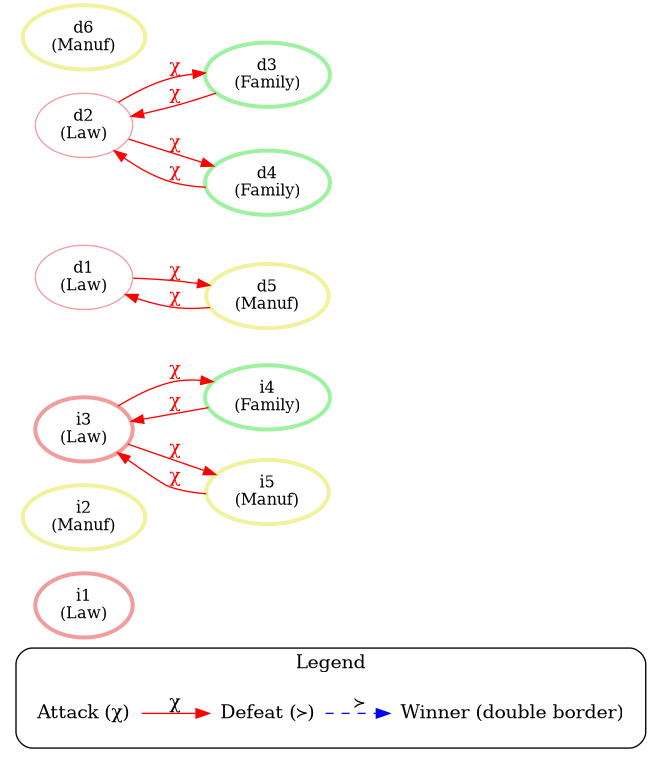

In [13]:
try:
    av = ArgumentationVisualizer()
    av.build_graph(
        arguments=args_final,
        winners={A.hd for A in accepted},
        priorities=jim.priorities,
        contrariness=jim.contrariness
    )
    
    graph_name = "jiminy_scenario_graph"
    av.render(graph_name)
    display(Image(filename=f"{graph_name}.png"))
except Exception as e:
    print(f"Visualization skipped/failed: {e}")

## Graphviz Advanced Exports

This section implements the logic from `--export-graphviz` in the CLI.

Generating and displaying advanced Graphviz exports...


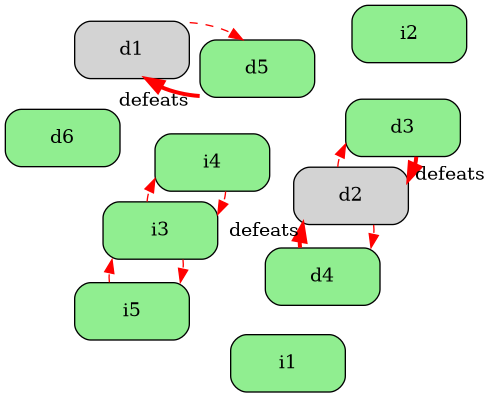

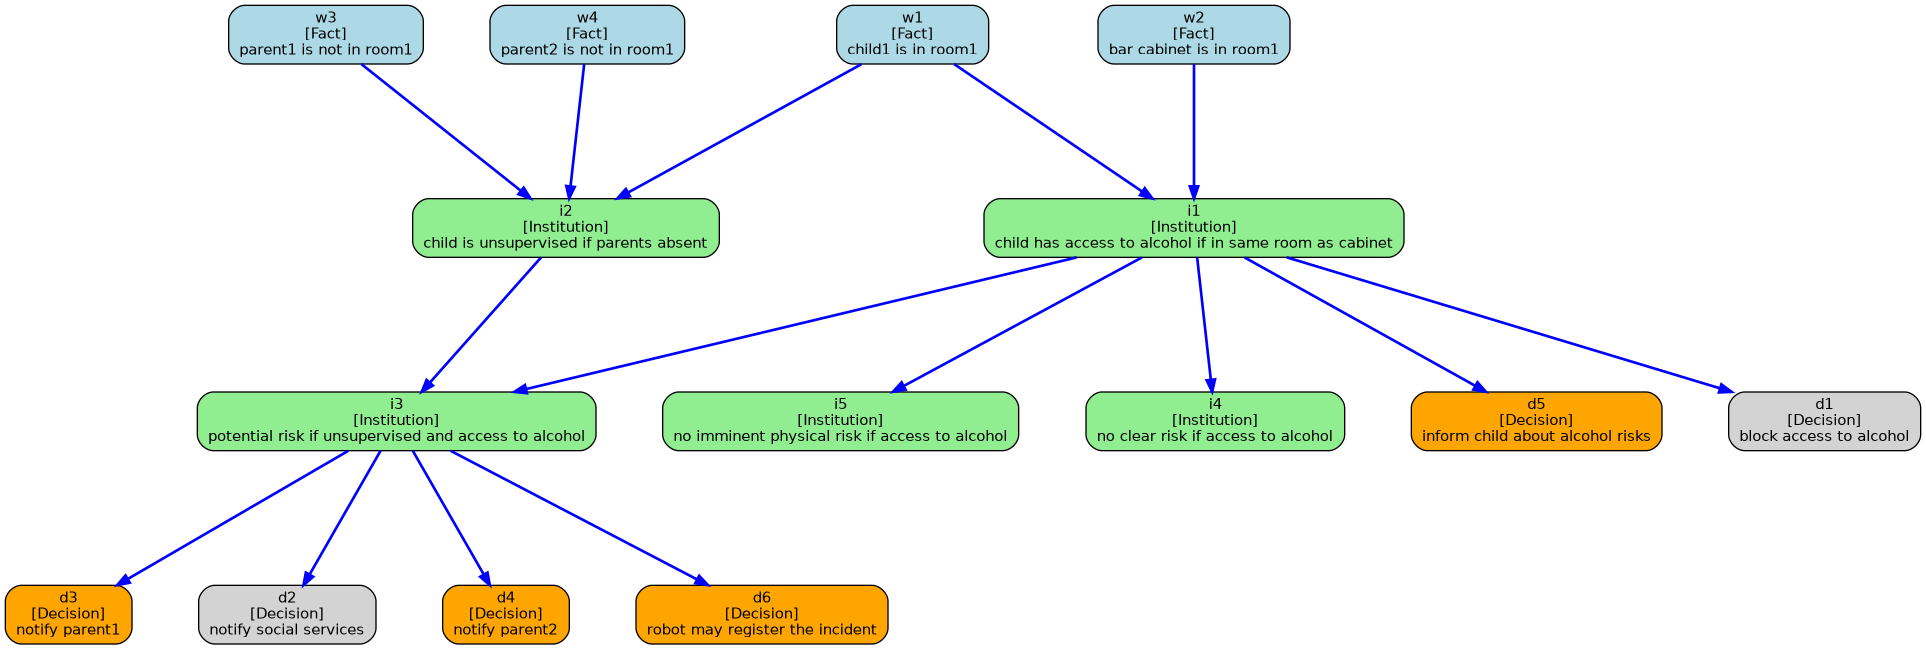

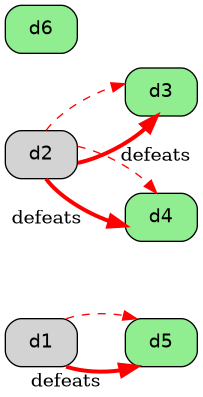

In [14]:
def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_graphviz(path):
    g = Digraph("Argumentation Framework", engine="neato")
    g.attr(overlap="false")
    g.attr(splines="spline")
    g.attr(rankdir="TB", ranksep="1.5", nodesep="1.0")

    winners = {A.hd for A in accepted}

    for A in args_final:
        color = "lightgreen" if A.hd in winners else "lightgray"
        g.node(A.hd, A.hd, width="1.2", height="0.6", shape="box", style="filled,rounded", fillcolor=color)

    for A in args_final:
        for B in args_final:
            if jim.attacks(A, B):
                if A.hd in winners and B.hd not in winners:
                    g.edge(A.hd, B.hd, color="red", penwidth="3", xlabel="defeats", arrowsize="1.2")
                else:
                    g.edge(A.hd, B.hd, color="red", style="dashed")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")
    
    winners = {A.hd for A in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []

    for A in args_final:
        head = A.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)

        body = getattr(A.origin_norm, "body", [])
        for b in body:
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions: 
        color = "orange" if d in winners else "lightgray"
        g.node(d, label=build_label(d), fillcolor=color)

    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")
    
    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

def export_defeat_graph(path):
    g = Digraph("Jiminy Defeat", engine="dot")
    g.attr(rankdir="LR", splines="curved", nodesep="0.8")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica")
    
    winners = {A.hd for A in accepted}
    for A in args_final:
        if not A.hd.startswith("d"): continue
        color = "lightgreen" if A.hd in winners else "lightgray"
        g.node(A.hd, fillcolor=color)

    for A in args_final:
        for B in args_final:
            if not (A.hd.startswith("d") and B.hd.startswith("d")): continue
            if jim.attacks(A, B):
                if A.hd in winners and B.hd not in winners:
                    g.edge(A.hd, B.hd, color="red", penwidth="3", arrowsize="1.2", xlabel="defeats")
                else:
                    g.edge(A.hd, B.hd, color="red", style="dashed")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

print("Generating and displaying advanced Graphviz exports...")
display(Image(filename=export_graphviz("jiminy_af")))
display(Image(filename=export_reasoning_graph("jiminy_reasoning")))
display(Image(filename=export_defeat_graph("jiminy_defeat")))